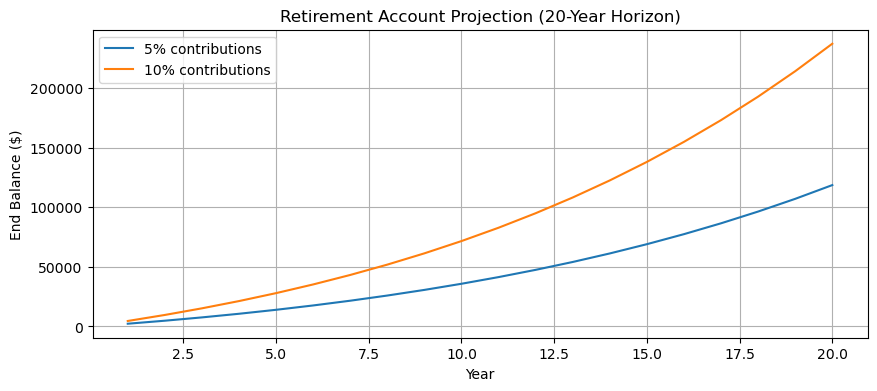

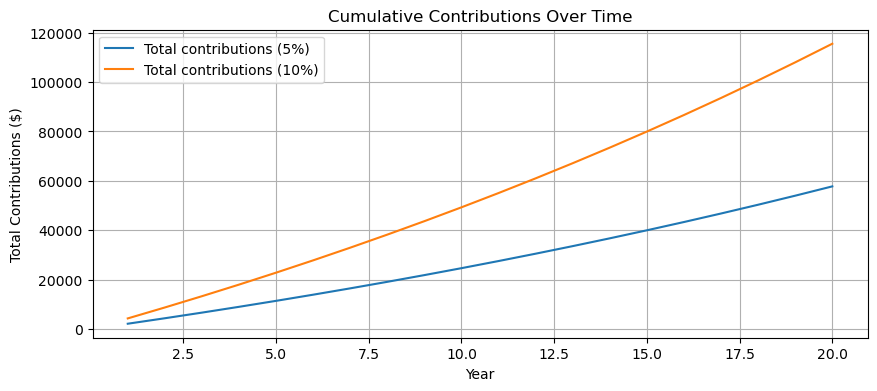

Scenario Summary:


,Contribution Rate,Final Balance ($),Total Contributions ($),Investment Growth ($)
0,5%,118681.26,57771.31,60909.95
1,10%,237362.51,115542.61,121819.90


Year-by-year schedule (Contribution Rate = 10%):


,Year,Salary,Contribution Rate,Annual Contribution,End Balance,Total Contributions (to date),Investment Growth (to date)
0,1,43000.000000,0.1,4300.000000,4601.000000,4300.000000,301.000000
1,2,44290.000000,0.1,4429.000000,9662.100000,8729.000000,933.100000
2,3,45618.700000,0.1,4561.870000,15219.647900,13290.870000,1928.777900
3,4,46987.261000,0.1,4698.726100,21312.660180,17989.596100,3323.064080
4,5,48396.878830,0.1,4839.687883,27983.012427,22829.283983,5153.728444
5,6,49848.785195,0.1,4984.878519,35275.643313,27814.162502,7461.480811
6,7,51344.248751,0.1,5134.424875,43238.772961,32948.587378,10290.185584
7,8,52884.576213,0.1,5288.457621,51924.136724,38237.044999,13687.091725
8,9,54471.113500,0.1,5447.111350,61387.235439,43684.156349,17703.079090
9,10,56105.246905,0.1,5610.524690,71687.603338,49294.681039,22392.922299


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


starting_salary = 43000 
salary_growth = 0.03           
expected_return = 0.07         
years = 20                     

contribution_rates = [0.05, 0.10]   

starting_balance = 0      

def project_retirement(contribution_rate: float) -> pd.DataFrame:
    salary = starting_salary
    balance = starting_balance
    rows = []

    for year in range(1, years + 1):
        contribution = salary * contribution_rate
        balance = (balance + contribution) * (1 + expected_return)

        rows.append({
            "Year": year,
            "Salary": salary,
            "Contribution Rate": contribution_rate,
            "Annual Contribution": contribution,
            "End Balance": balance
        })

        salary *= (1 + salary_growth)

    df = pd.DataFrame(rows)
    df["Total Contributions (to date)"] = df["Annual Contribution"].cumsum()
    df["Investment Growth (to date)"] = df["End Balance"] - df["Total Contributions (to date)"] - starting_balance
    return df

scenario_dfs = {cr: project_retirement(cr) for cr in contribution_rates}

summary_rows = []
for cr, df in scenario_dfs.items():
    final_balance = df["End Balance"].iloc[-1]
    total_contrib = df["Annual Contribution"].sum()
    investment_growth = final_balance - total_contrib - starting_balance

    summary_rows.append({
        "Contribution Rate": f"{int(cr*100)}%",
        "Final Balance ($)": round(final_balance, 2),
        "Total Contributions ($)": round(total_contrib, 2),
        "Investment Growth ($)": round(investment_growth, 2),
    })

summary = pd.DataFrame(summary_rows)


plt.figure(figsize=(10, 4))
for cr, df in scenario_dfs.items():
    plt.plot(df["Year"], df["End Balance"], label=f"{int(cr*100)}% contributions")
plt.title(f"Retirement Account Projection ({years}-Year Horizon)")
plt.xlabel("Year")
plt.ylabel("End Balance ($)")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(10, 4))
for cr, df in scenario_dfs.items():

    plt.plot(df["Year"], df["Total Contributions (to date)"], label=f"Total contributions ({int(cr*100)}%)")
plt.title("Cumulative Contributions Over Time")
plt.xlabel("Year")
plt.ylabel("Total Contributions ($)")
plt.grid(True)
plt.legend()
plt.show()


print("Scenario Summary:")
display(summary)


max_cr = max(contribution_rates)
print(f"Year-by-year schedule (Contribution Rate = {int(max_cr*100)}%):")
display(scenario_dfs[max_cr].head(10))
